# Notebook 3: Probabilistic Classification — Logistic Regression

**Block 2 — Probabilistic Classification**

In this notebook we apply the **same probabilistic recipe** from Block 1, but now for classification:

$$y \mid \mathbf{x} \sim \text{Bernoulli}\bigl(\sigma(\mathbf{w}^\top \mathbf{x} + b)\bigr)$$

We will:
1. Build a logistic regression model in Pyro.
2. Train via MLE (same SVI setup as Block 1).
3. Analyze **confident vs. uncertain** predictions.
4. Evaluate **calibration** — are the predicted probabilities reliable?

## 0. Setup

In [1]:
!pip install pyro-ppl scikit-learn -q

You should consider upgrading via the '/Users/zp25hk/Library/CloudStorage/GoogleDrive-andresrmasegosa@gmail.com/My Drive/teaching/2026-Spring/2026-PhD-PML-Claude/.venv/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

pyro.set_rng_seed(42)
torch.manual_seed(42)
np.random.seed(42)
pyro.clear_param_store()

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12
FIGURES_DIR = 'figures/'
import os
os.makedirs(FIGURES_DIR, exist_ok=True)


## 1. Classification data

We use `make_moons` — a classic 2D binary classification dataset.

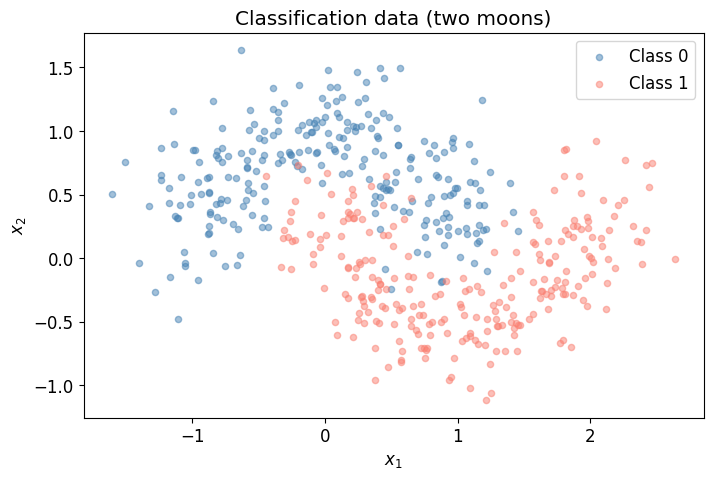

In [3]:
# Generate data
X_np, y_np = make_moons(n_samples=500, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.3, random_state=42)

X_train, y_train = make_moons(n_samples=500, noise=0.25, random_state=42)
X_test, y_test = make_moons(n_samples=5000, noise=0.25, random_state=42)


x_train = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
x_test = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], alpha=0.5, s=20, label='Class 0', color='steelblue')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], alpha=0.5, s=20, label='Class 1', color='salmon')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.title('Classification data (two moons)')
plt.legend()
plt.savefig(f'{FIGURES_DIR}classification_data.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Probabilistic logistic regression model

Compare with Notebook 1:

| Block 1 (Regression) | Block 2 (Classification) |
|:--|:--|
| `dist.Normal(mean, sigma)` | `dist.Bernoulli(logits=logits)` |
| continuous $y$ | binary $y \in \{0,1\}$ |

Everything else (param, plate, SVI) is **identical**.

In [4]:
def logistic_regression_model(x, y=None):
    """
    Probabilistic logistic regression.
    y | x ~ Bernoulli(sigmoid(w^T x + b))
    """
    D = x.shape[1]  # input dimension
    
    # Learnable parameters
    w = pyro.param('w', torch.zeros(D))
    b = pyro.param('b', torch.tensor(0.0))
    
    # Logits (before sigmoid)
    logits = x @ w + b
    
    # Observations
    with pyro.plate('data', len(x)):
        pyro.sample('obs', dist.Bernoulli(logits=logits), obs=y)

# Note: we use logits= instead of probs= for numerical stability.
# Pyro applies the sigmoid internally.
# No sigma parameter needed — Bernoulli has no noise parameter!

def empty_guide(x, y=None):
    pass

print('Model defined. Compare with Notebook 1:')
print('  Regression:     dist.Normal(mean, sigma)')
print('  Classification: dist.Bernoulli(logits=logits)')
print('Everything else is the same!')

Model defined. Compare with Notebook 1:
  Regression:     dist.Normal(mean, sigma)
  Classification: dist.Bernoulli(logits=logits)
Everything else is the same!


## 3. Training (same SVI setup)

Step  250 | Loss: 151.03
Step  500 | Loss: 150.92
Step  750 | Loss: 150.92
Step 1000 | Loss: 150.92


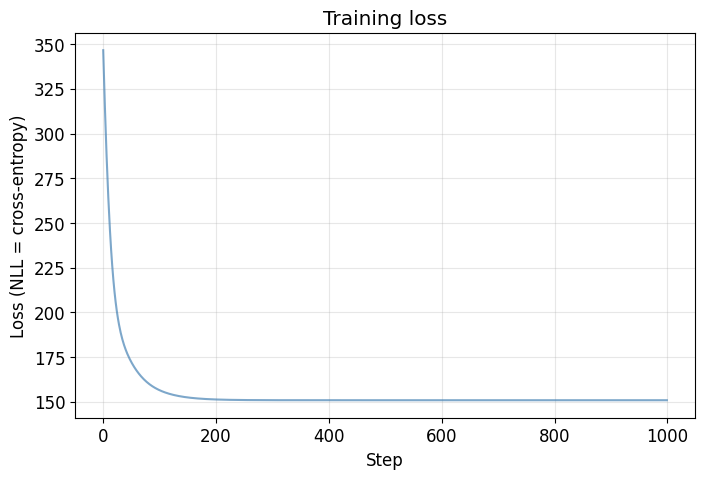


Note: this loss is the cross-entropy — it comes from the Bernoulli model.


In [5]:
pyro.clear_param_store()
svi = SVI(logistic_regression_model, empty_guide, Adam({'lr': 0.05}), loss=Trace_ELBO())

losses = []
for step in range(1000):
    loss = svi.step(x_train, y_train_t)
    losses.append(loss)
    if (step + 1) % 250 == 0:
        print(f'Step {step+1:4d} | Loss: {loss:.2f}')

plt.plot(losses, color='steelblue', alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss (NLL = cross-entropy)')
plt.title('Training loss'); plt.grid(True, alpha=0.3)
plt.show()

print(f'\nNote: this loss is the cross-entropy — it comes from the Bernoulli model.')

## 4. Predictions: class vs. probability

The key advantage: we get **probabilities**, not just class labels.

In [6]:
# Predict on test set
w_learned = pyro.param('w').detach()
b_learned = pyro.param('b').detach().item()

logits_test = x_test @ w_learned + b_learned
probs_test = torch.sigmoid(logits_test)
preds_test = (probs_test > 0.5).float()

accuracy = (preds_test == y_test_t).float().mean().item()
print(f'Test accuracy: {accuracy:.3f}')

Test accuracy: 0.860


### 4.1 Decision boundary with probability contours

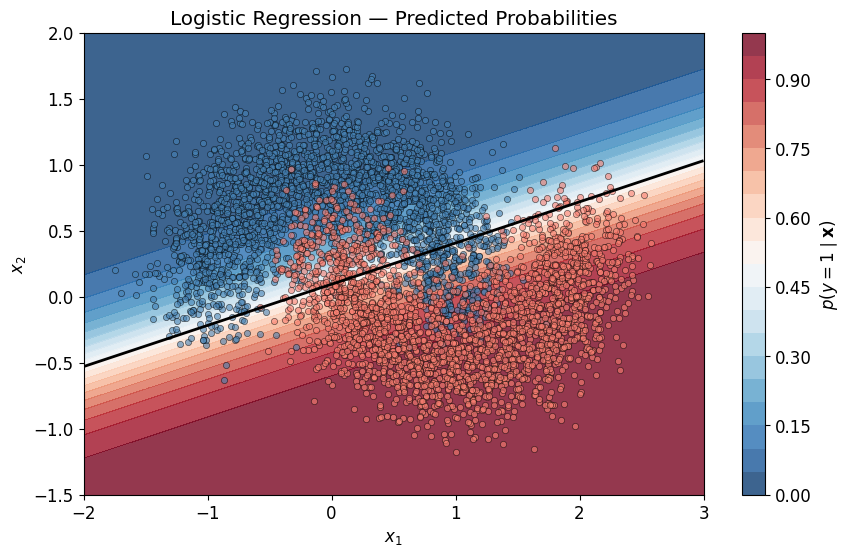

Colors show p(y=1|x). Black line = decision boundary (p=0.5).
Points near the boundary have uncertain predictions.


In [7]:
# Create a grid for decision boundary
xx, yy = np.meshgrid(np.linspace(-2, 3, 200), np.linspace(-1.5, 2, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    grid_probs = torch.sigmoid(grid @ w_learned + b_learned).numpy().reshape(xx.shape)

plt.figure(figsize=(10, 6))
contour = plt.contourf(xx, yy, grid_probs, levels=20, cmap='RdBu_r', alpha=0.8)
plt.colorbar(contour, label='$p(y=1 \mid \mathbf{x})$')
plt.contour(xx, yy, grid_probs, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], s=20, alpha=0.6, c='steelblue', edgecolors='k', linewidths=0.5)
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], s=20, alpha=0.6, c='salmon', edgecolors='k', linewidths=0.5)
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.title('Logistic Regression — Predicted Probabilities')
plt.savefig(f'{FIGURES_DIR}logistic_decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()

print('Colors show p(y=1|x). Black line = decision boundary (p=0.5).')
print('Points near the boundary have uncertain predictions.')

### 4.2 Confident vs. uncertain examples

In [8]:
# Sort test examples by confidence (distance from 0.5)
confidence = torch.abs(probs_test - 0.5)
sorted_idx = torch.argsort(confidence)

print('=== Most UNCERTAIN predictions (probability close to 0.5) ===')
for i in sorted_idx[:5]:
    print(f'  x={x_test[i].numpy()}, p(y=1)={probs_test[i].item():.3f}, true y={y_test[i]}')

print()
print('=== Most CONFIDENT predictions (probability close to 0 or 1) ===')
for i in sorted_idx[-5:]:
    print(f'  x={x_test[i].numpy()}, p(y=1)={probs_test[i].item():.3f}, true y={y_test[i]}')

print()
# Overconfident errors
errors = preds_test != y_test_t
if errors.any():
    error_probs = probs_test[errors]
    error_conf = torch.abs(error_probs - 0.5)
    print(f'=== Errors: {errors.sum().item()} misclassifications ===')
    worst_errors = torch.argsort(error_conf, descending=True)
    error_indices = torch.where(errors)[0]
    for j in worst_errors[:5]:
        i = error_indices[j]
        print(f'  x={x_test[i].numpy()}, p(y=1)={probs_test[i].item():.3f}, true y={y_test[i]} <-- WRONG')

=== Most UNCERTAIN predictions (probability close to 0.5) ===
  x=[-0.5678169  -0.08201303], p(y=1)=0.500, true y=0
  x=[1.5981872 0.5922931], p(y=1)=0.501, true y=0
  x=[-0.59851044 -0.09038582], p(y=1)=0.498, true y=0
  x=[2.2151654  0.78386533], p(y=1)=0.502, true y=1
  x=[-0.6891547  -0.12255286], p(y=1)=0.502, true y=0

=== Most CONFIDENT predictions (probability close to 0 or 1) ===
  x=[-0.31140348  1.603906  ], p(y=1)=0.001, true y=0
  x=[ 1.3820168 -1.1179572], p(y=1)=0.999, true y=1
  x=[-0.1282553  1.7080199], p(y=1)=0.001, true y=0
  x=[ 1.9646775  -0.98191494], p(y=1)=0.999, true y=1
  x=[ 1.6315659 -1.1537292], p(y=1)=0.999, true y=1

=== Errors: 699 misclassifications ===
  x=[ 1.3308514  -0.60446376], p(y=1)=0.991, true y=0 <-- WRONG
  x=[-0.32741424  0.96507084], p(y=1)=0.016, true y=1 <-- WRONG
  x=[ 1.1258141  -0.51886857], p(y=1)=0.984, true y=0 <-- WRONG
  x=[ 1.729654   -0.19553626], p(y=1)=0.971, true y=0 <-- WRONG
  x=[-0.3670532   0.80720294], p(y=1)=0.029, tru

## 5. Calibration analysis

A well-calibrated model's predicted probabilities match observed frequencies.

We compute a **reliability diagram**: we bin predictions by their predicted probability, then check how often those predictions are actually correct.

In [9]:
def reliability_diagram(probs, labels, n_bins=10, ax=None, title='Reliability Diagram', color='steelblue'):
    """
    Plot a reliability diagram.
    
    Args:
        probs: predicted probabilities (numpy array)
        labels: true binary labels (numpy array)
        n_bins: number of bins
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    bin_accs = []
    bin_confs = []
    bin_counts = []
    
    for i in range(n_bins):
        mask = (probs >= bin_edges[i]) & (probs < bin_edges[i+1])
        if mask.sum() > 0:
            bin_accs.append(labels[mask].mean())
            bin_confs.append(probs[mask].mean())
            bin_counts.append(mask.sum())
        else:
            bin_accs.append(np.nan)
            bin_confs.append(np.nan)
            bin_counts.append(0)
    
    bin_accs = np.array(bin_accs)
    bin_confs = np.array(bin_confs)
    
    # Plot
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
    ax.bar(bin_centers, bin_accs, width=1/n_bins * 0.8, alpha=0.7, color=color, edgecolor='k', linewidth=0.5)
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Observed frequency')
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.set_aspect('equal')
    
    # ECE (Expected Calibration Error)
    valid = ~np.isnan(bin_accs)
    counts = np.array(bin_counts)
    if valid.any():
        ece = np.average(np.abs(bin_accs[valid] - bin_confs[valid]), weights=counts[valid])
        ax.text(0.05, 0.9, f'ECE = {ece:.3f}', transform=ax.transAxes, fontsize=12)
    
    return ax

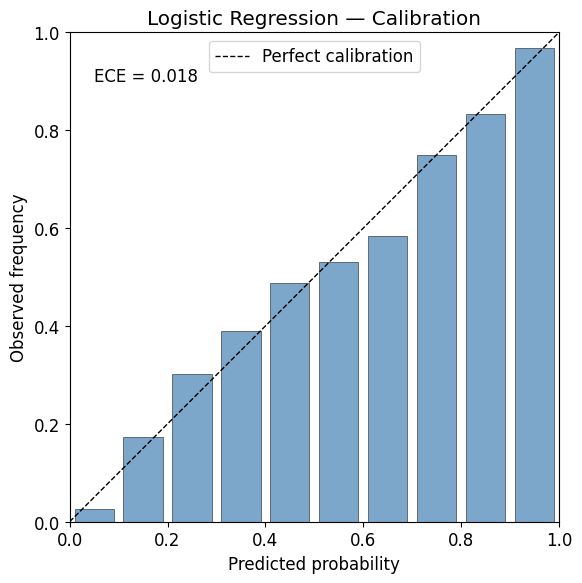

Bars close to the diagonal = well calibrated.
Logistic regression is typically well calibrated.


In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
reliability_diagram(probs_test.numpy(), y_test, n_bins=10, ax=ax, 
                    title='Logistic Regression — Calibration')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}logistic_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print('Bars close to the diagonal = well calibrated.')
print('Logistic regression is typically well calibrated.')

## 6. Summary

What we learned:

- **Same Pyro structure** as regression: `pyro.param`, `pyro.plate`, `pyro.sample`.
- Only the **distribution** changes: `Normal` → `Bernoulli`.
- The NLL becomes **cross-entropy** (not MSE).
- We get **probabilities**, not just class labels — this lets us identify uncertain predictions.
- **Calibration** measures whether those probabilities are reliable.

**Next:** Notebook 4 will replace the linear model with a neural network and compare calibration.

---
## 7. Exercise: Multi-class Classification

So far we have worked with **binary** classification ($y \in \{0,1\}$) using a Bernoulli distribution.

In many real problems there are **more than two classes** (e.g., digit recognition, disease subtypes, document topics). The probabilistic recipe is the same — only the distribution changes:

| Binary | Multi-class ($K$ classes) |
|:-------|:------------------------|
| $\text{Bernoulli}(\sigma(z))$ | $\text{Categorical}(\text{softmax}(\mathbf{z}))$ |
| sigmoid: $\mathbb{R} \to [0,1]$ | softmax: $\mathbb{R}^K \to \Delta^{K-1}$ |
| 1 logit | $K$ logits |

### What you need to do

1. **Complete the multi-class model** in Section 7.2: replace `dist.Bernoulli(logits=...)` with `dist.Categorical(logits=...)`. The parameters become a weight **matrix** $W \in \mathbb{R}^{D \times K}$ and a bias **vector** $\mathbf{b} \in \mathbb{R}^K$ (one logit per class).
2. **Train via SVI** (same setup as before) and check the loss converges.
3. **Compute predictions** and test accuracy.
4. **Evaluate calibration** using the reliability diagram — adapted for multi-class.

---

### Step-by-step hints

**Hint 1 — Model structure.**
```python
def multiclass_model(x, y=None):
    K = 3   # number of classes
    D = x.shape[1]
    W = pyro.param('W', torch.zeros(D, K))
    b = pyro.param('b_mc', torch.zeros(K))
    logits = x @ W + b                        # shape: [N, K]
    with pyro.plate('data', len(x)):
        pyro.sample('obs', dist.Categorical(logits=logits), obs=y)
```
`dist.Categorical(logits=...)` applies softmax internally (just like `dist.Bernoulli(logits=...)` applies sigmoid).

**Hint 2 — Predictions.**
After training, get predicted probabilities with:
```python
probs = torch.softmax(x_test @ W_learned + b_learned, dim=-1)  # shape [N, 3]
pred_classes = probs.argmax(dim=-1)
```

**Hint 3 — Multi-class calibration.**
For each test point, the model's "confidence" is `probs.max(dim=-1).values` (the probability assigned to the predicted class). The reliability diagram compares this confidence against the actual accuracy within each bin — exactly the same logic as Section 5, but using the confidence of the predicted class rather than $p(y=1)$.

---

### Questions to answer

1. What test accuracy does the multi-class logistic regression achieve?
2. How does the reliability diagram look? Is the model well-calibrated?
3. Are there regions in input space where the model is uncertain between all three classes?
4. What is the connection between `dist.Categorical` here and the clustering model in Block 3?

### 7.1 Data generation

We provide the data — you focus on the model.

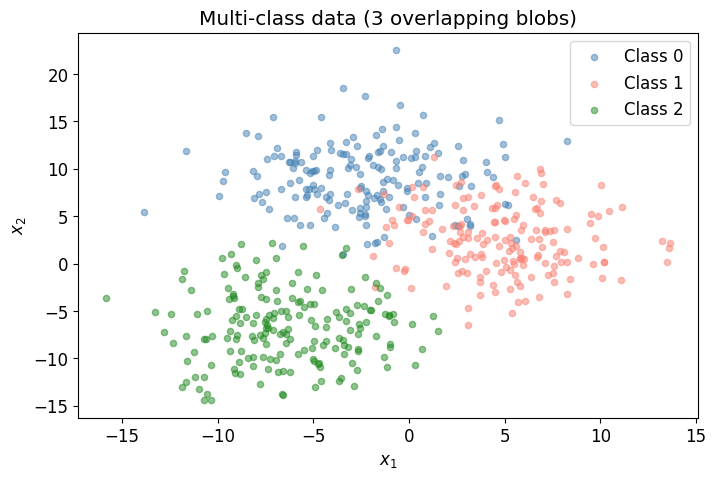

Train: 525, Test: 225, Classes: 3


In [11]:
from sklearn.datasets import make_blobs

# --- Generate 3-class data ---
# We use cluster_std=3.5 to get overlapping classes — this makes
# calibration interesting (with well-separated blobs, accuracy = 100%).
X_mc, y_mc = make_blobs(n_samples=750, centers=3, cluster_std=3.5, random_state=42)
X_mc_train, X_mc_test, y_mc_train, y_mc_test = train_test_split(X_mc, y_mc, test_size=0.3, random_state=42)

x_mc_train = torch.tensor(X_mc_train, dtype=torch.float32)
y_mc_train_t = torch.tensor(y_mc_train, dtype=torch.long)  # NOTE: torch.long, not float!
x_mc_test = torch.tensor(X_mc_test, dtype=torch.float32)
y_mc_test_t = torch.tensor(y_mc_test, dtype=torch.long)

# Plot
plt.figure(figsize=(8, 5))
colors = ['steelblue', 'salmon', 'forestgreen']
for k in range(3):
    mask = y_mc_train == k
    plt.scatter(X_mc_train[mask, 0], X_mc_train[mask, 1], alpha=0.5, s=20,
                label=f'Class {k}', color=colors[k])
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.title('Multi-class data (3 overlapping blobs)')
plt.legend()
plt.show()

print(f'Train: {len(x_mc_train)}, Test: {len(x_mc_test)}, Classes: 3')

In [12]:
# --- Step 2: Define the multi-class model ---
# TODO: Complete the model below.
# Replace the Bernoulli with Categorical, and change w (vector) to W (matrix).

def multiclass_model(x, y=None):
    K = 3   # number of classes
    D = x.shape[1]

    # TODO: declare W as a pyro.param of shape (D, K) and b as a pyro.param of shape (K)
    W = ...   # ← YOUR CODE HERE
    b = ...   # ← YOUR CODE HERE

    # TODO: compute logits of shape [N, K]
    logits = ...   # ← YOUR CODE HERE

    with pyro.plate('data', len(x)):
        # TODO: replace ... with dist.Categorical(logits=logits)
        pyro.sample('obs', ..., obs=y)   # ← YOUR CODE HERE


# --- Step 3: Train via SVI ---
# (This cell will only work once you complete the model above!)
pyro.clear_param_store()

svi_mc = SVI(multiclass_model, empty_guide, Adam({'lr': 0.05}), loss=Trace_ELBO())

losses_mc = []
for step in range(1000):
    loss = svi_mc.step(x_mc_train, y_mc_train_t)
    losses_mc.append(loss)
    if (step + 1) % 250 == 0:
        print(f'Step {step+1:4d} | Loss: {loss:.2f}')

plt.plot(losses_mc, color='steelblue', alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss (NLL)')
plt.title('Training loss — Multi-class'); plt.grid(True, alpha=0.3)
plt.show()

AttributeError: 'ellipsis' object has no attribute 'log_prob'

In [ ]:
# --- Step 4: Predictions and accuracy ---
W_learned = pyro.param('W').detach()
b_learned = pyro.param('b_mc').detach()

logits_mc = x_mc_test @ W_learned + b_learned
probs_mc = torch.softmax(logits_mc, dim=-1)         # shape [N, 3]
pred_classes = probs_mc.argmax(dim=-1)

accuracy_mc = (pred_classes == y_mc_test_t).float().mean().item()
print(f'Multi-class test accuracy: {accuracy_mc:.3f}')

# --- Visualization: predicted class probabilities ---
# TODO: Create a figure with 3 subplots (one per class).
# For each class k, show a contour plot of p(y=k | x) over a grid.
#
# Skeleton:
# xx, yy = np.meshgrid(np.linspace(...), np.linspace(...))
# grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
# grid_probs = torch.softmax(grid @ W_learned + b_learned, dim=-1)
#
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# for k in range(3):
#     probs_k = grid_probs[:, k].numpy().reshape(xx.shape)
#     axes[k].contourf(xx, yy, probs_k, levels=20, cmap='RdBu_r', alpha=0.8)
#     axes[k].set_title(f'p(y={k} | x)')
# plt.show()

In [ ]:
# --- Step 5: Multi-class calibration ---
# For multi-class, we measure calibration using the CONFIDENCE of the predicted class:
#   confidence = max_k p(y=k | x)
#   correct    = 1 if predicted class matches true class, 0 otherwise
#
# The reliability diagram then checks: when the model says "I'm 80% confident",
# is it actually correct 80% of the time?

confidence = probs_mc.max(dim=-1).values.numpy()
correct = (pred_classes == y_mc_test_t).float().numpy()

fig, ax = plt.subplots(figsize=(6, 6))
reliability_diagram(confidence, correct, n_bins=10, ax=ax,
                    title='Multi-class Logistic Regression — Calibration')
plt.tight_layout()
plt.show()

print(f'Test accuracy: {accuracy_mc:.3f}')
print('Is the multi-class model well-calibrated?')
print('Compare with the binary logistic regression from Section 5.')

---

<details>
<summary><b>Click here to reveal the solution</b></summary>

### Solution: Multi-class Classification

Below is the complete solution. Try to solve the exercise on your own before looking!

</details>

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# SOLUTION — Exercise 7: Multi-class Classification
# ═══════════════════════════════════════════════════════════════════

# --- Step 2 (solution): Define the multi-class model ---
def multiclass_model_solution(x, y=None):
    K = 3   # number of classes
    D = x.shape[1]

    # Weight matrix: one column per class
    W = pyro.param('W', torch.zeros(D, K))
    # Bias vector: one entry per class
    b = pyro.param('b_mc', torch.zeros(K))

    # Logits: [N, K] — one score per class per data point
    logits = x @ W + b

    with pyro.plate('data', len(x)):
        # Categorical applies softmax internally, just like Bernoulli applies sigmoid
        pyro.sample('obs', dist.Categorical(logits=logits), obs=y)


# --- Step 3 (solution): Train via SVI ---
pyro.clear_param_store()

svi_mc_sol = SVI(multiclass_model_solution, empty_guide, Adam({'lr': 0.05}), loss=Trace_ELBO())

losses_mc_sol = []
for step in range(1000):
    loss = svi_mc_sol.step(x_mc_train, y_mc_train_t)
    losses_mc_sol.append(loss)
    if (step + 1) % 250 == 0:
        print(f'Step {step+1:4d} | Loss: {loss:.2f}')

plt.plot(losses_mc_sol, color='steelblue', alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss (NLL)')
plt.title('Training loss — Multi-class'); plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# --- Step 4 (solution): Predictions and visualization ---
W_learned = pyro.param('W').detach()
b_learned = pyro.param('b_mc').detach()

logits_mc = x_mc_test @ W_learned + b_learned
probs_mc = torch.softmax(logits_mc, dim=-1)
pred_classes = probs_mc.argmax(dim=-1)

accuracy_mc = (pred_classes == y_mc_test_t).float().mean().item()
print(f'Multi-class test accuracy: {accuracy_mc:.3f}')

# Contour plot: predicted probability for each class
x_min, x_max = X_mc[:, 0].min() - 1, X_mc[:, 0].max() + 1
y_min, y_max = X_mc[:, 1].min() - 1, X_mc[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
grid_probs = torch.softmax(grid @ W_learned + b_learned, dim=-1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_map = ['Blues', 'Reds', 'Greens']
colors_scatter = ['steelblue', 'salmon', 'forestgreen']
for k in range(3):
    probs_k = grid_probs[:, k].detach().numpy().reshape(xx.shape)
    axes[k].contourf(xx, yy, probs_k, levels=20, cmap=colors_map[k], alpha=0.8)
    for c in range(3):
        mask = y_mc_test == c
        axes[k].scatter(X_mc_test[mask, 0], X_mc_test[mask, 1], s=10, alpha=0.4,
                       color=colors_scatter[c], edgecolors='k', linewidths=0.3)
    axes[k].set_title(f'$p(y={k} \\mid \\mathbf{{x}})$')
    axes[k].set_xlabel('$x_1$'); axes[k].set_ylabel('$x_2$')

plt.suptitle('Multi-class logistic regression — per-class probabilities', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# --- Step 5 (solution): Multi-class calibration ---
confidence = probs_mc.max(dim=-1).values.numpy()
correct = (pred_classes == y_mc_test_t).float().numpy()

fig, ax = plt.subplots(figsize=(6, 6))
reliability_diagram(confidence, correct, n_bins=10, ax=ax,
                    title='Multi-class Logistic Regression — Calibration')
plt.tight_layout()
plt.show()

print(f'Test accuracy: {accuracy_mc:.3f}')
print()
print('Answers:')
print('1. The accuracy should be around 93-94% (blobs overlap significantly).')
print('2. Logistic regression is typically well-calibrated, even in multi-class.')
print('3. Yes — near the center where all 3 clusters meet, confidence drops to ~0.5.')
print('4. dist.Categorical is the SAME distribution used in GMM (Block 3).')
print('   In GMM, the Categorical assigns data points to clusters (latent variable).')
print('   Here, it models the observed class label (observed variable).')